# Square J-Lens word recurrence in five-shot addition

Reads completed artifacts only; no model loading, generation, or lens scoring.
Words/wordpieces are stripped, case-folded single-token predictions. They are not sentences.
The complete prompt condition changes filler in every demonstration as well as the target.
All intervals are descriptive 2,000-resample paired-fact bootstrap intervals (seed 42).


In [1]:
from pathlib import Path
import sys
ROOT = Path('/pscratch/sd/m/marocco/sandbox/mech_int')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from filler.dsv4.five_shot_recurrence import DEFAULT_ROOT, read
from filler.dsv4.recurrence_export import load_completed, plot_word, inspect_cell
RUN = DEFAULT_ROOT
RUN = load_completed(RUN)
validation = read(RUN / 'validation.json')
groups = read(RUN / 'selected_groups.json')
representative = read(RUN / 'representative.json')
print(validation)


{'cohort_source': 'strict integer answers from this capture run', 'complete_five_shot_position_coverage': True, 'config_hash': 'b0d4296587f3e4e7df89ec7b5f2d0dfaec752e4651fc7d3882ac0243b6ea0e1f', 'historical_label_disagreements': 25, 'max_native_logprob_error': 0.0, 'native_checks': 524, 'passed': True, 'prompts': 524, 'readouts': 330120, 'selected_groups': 20, 'square_layers': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]}


## Filters and ranked tables

Change `COHORT`, `CATEGORY`, `TOKEN_FILTER`, and `KIND` to inspect all/correct/wrong prompts,
fact categories, textual groups/numbers/punctuation/special tokens, or exact token IDs.
The condition-specific recurrence tables use each capture's own strict correctness label.
Paired difference cohorts are fixed by k20 correctness, so both conditions contain identical facts.


In [2]:
COHORT = 'all'       # all, correct, wrong
CATEGORY = 'all'     # see cohorts table for fact categories
TOKEN_FILTER = 'textual'  # textual, number, punctuation, special, whitespace, all
KIND = 'group'       # group or token
cohorts = pd.read_csv(RUN / 'tables/cohorts.csv')
display(cohorts)
leaders = pd.read_csv(RUN / 'tables/recurrence.csv.gz', keep_default_na=False)
selected = leaders[(leaders.k == 20) & (leaders.region == 'filler') & (leaders.cohort == COHORT)
                   & (leaders.category == CATEGORY) & (leaders.kind == KIND)]
if TOKEN_FILTER != 'all':
    selected = selected[selected['filter'] == TOKEN_FILTER]
display(selected.sort_values(['persistence', 'breadth', 'text'], ascending=[False, False, True]).head(30))


,k,category,cohort,n_prompts
0,0,all,all,262
1,0,all,correct,137
2,0,all,wrong,125
3,0,age_facts,all,78
4,0,age_facts,correct,21
5,0,age_facts,wrong,57
6,0,atomic_facts,all,99
7,0,atomic_facts,correct,72
8,0,atomic_facts,wrong,27
9,0,static_facts,all,85


,k,region,category,cohort,kind,item_id,text,filter,n_prompts,cells_per_prompt,...,in_question_fraction,persistence,persistence_low,persistence_high,breadth,breadth_low,breadth_high,top1,top1_low,top1_high
756774,20,filler,all,all,group,98243,锁定,textual,262,840,...,0.0,0.300627,0.299109,0.302095,0.999998,1.0,1.0,0.126418,0.124796,0.127931
740380,20,filler,all,all,group,8782,ait,textual,262,840,...,0.0,0.278558,0.277003,0.280066,0.999998,1.0,1.0,0.009578,0.009033,0.010128
749993,20,filler,all,all,group,49448,walker,textual,262,840,...,0.0,0.273023,0.271047,0.274968,0.999998,1.0,1.0,0.054308,0.052558,0.056157
753447,20,filler,all,all,group,78672,并能,textual,262,840,...,0.0,0.267671,0.266098,0.269225,0.999998,1.0,1.0,0.039368,0.037872,0.040794
741773,20,filler,all,all,group,14247,cheer,textual,262,840,...,0.0,0.248878,0.247628,0.250164,0.999998,1.0,1.0,0.028771,0.027713,0.029903
748521,20,filler,all,all,group,43546,smile,textual,262,840,...,0.0,0.182811,0.180206,0.185283,0.999998,1.0,1.0,0.010810,0.010174,0.011446
750078,20,filler,all,all,group,49857,wig,textual,262,840,...,0.0,0.181311,0.179735,0.182811,0.999998,1.0,1.0,0.001172,0.001054,0.001304
749036,20,filler,all,all,group,45602,tears,textual,262,840,...,0.0,0.174505,0.172528,0.176622,0.999998,1.0,1.0,0.007166,0.006557,0.007802
753943,20,filler,all,all,group,81717,挪,textual,262,840,...,0.0,0.145402,0.144207,0.146615,0.999998,1.0,1.0,0.000145,0.000091,0.000204
740658,20,filler,all,all,group,9830,answer,textual,262,840,...,1.0,0.110878,0.108860,0.113178,0.999998,1.0,1.0,0.037432,0.036637,0.038219


## Recurrence heatmap and paired differences

The heatmap retains question, filler, answer-prefix and assistant-transition positions separately.
Choose a `GROUP_ID` from the ranked table. Paired heatmaps hold k20 cohort membership fixed.
The exact full-vocabulary group masses are saved even when the group is absent from the top ten.


In [3]:
GROUP_ID = groups[0]['group_id']
METRIC = 'top10'     # top1 or top10
fig = plot_word(RUN, GROUP_ID, cohort=COHORT, category=CATEGORY, metric=METRIC)
display(fig)
plt.close(fig)
differences = pd.read_csv(RUN / 'tables/paired_differences.csv')
display(differences[(differences.cohort_at_k20 == COHORT) & (differences.category == CATEGORY)
                    & (differences.group_id == GROUP_ID)])
probabilities = pd.read_csv(RUN / 'tables/probability_mass.csv')
display(probabilities[(probabilities.cohort == COHORT) & (probabilities.category == CATEGORY)
                     & (probabilities.group_id == GROUP_ID)])


RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 2400x1440 with 6 Axes>

,wordpiece,group_id,region,metric,category,cohort_at_k20,n_pairs,k0,k20,difference,low,high
0,锁定,98243,shared_all,top1,all,all,262,0.054635,0.051599,-0.003035,-0.004598,-0.001490
12,锁定,98243,shared_all,top10,all,all,262,0.180480,0.166158,-0.014322,-0.016467,-0.012214
24,锁定,98243,shared_all,probability_mass,all,all,262,0.005829,0.005494,-0.000335,-0.000414,-0.000258
36,锁定,98243,question,top1,all,all,262,0.006907,0.005816,-0.001091,-0.002819,0.000636
48,锁定,98243,question,top10,all,all,262,0.030443,0.037259,0.006816,0.003181,0.010453
60,锁定,98243,question,probability_mass,all,all,262,0.000938,0.000960,0.000022,-0.000103,0.000134
72,锁定,98243,answer_prefix,top1,all,all,262,0.065794,0.047937,-0.017857,-0.021265,-0.014357
84,锁定,98243,answer_prefix,top10,all,all,262,0.190794,0.145674,-0.045120,-0.048800,-0.041258
96,锁定,98243,answer_prefix,probability_mass,all,all,262,0.006841,0.005618,-0.001222,-0.001389,-0.001053
108,锁定,98243,assistant_transition,top1,all,all,262,0.067339,0.078153,0.010814,0.009224,0.012359


,k,region,category,cohort,wordpiece,group_id,n_prompts,probability_mass,low,high
0,0,question,all,all,锁定,98243,262,0.000938,0.000854,0.001045
240,0,answer_prefix,all,all,锁定,98243,262,0.006841,0.006686,0.006988
480,0,assistant_transition,all,all,锁定,98243,262,0.007264,0.007199,0.007330
720,20,question,all,all,锁定,98243,262,0.000960,0.000882,0.001046
960,20,filler,all,all,锁定,98243,262,0.008445,0.008378,0.008515
1200,20,answer_prefix,all,all,锁定,98243,262,0.005618,0.005550,0.005693
1440,20,assistant_transition,all,all,锁定,98243,262,0.007636,0.007575,0.007698


## Typical successful trajectory

The representative maximizes mean corresponding-position/layer top-ten overlap with all 262
k20 prompts, among prompts strictly correct in this capture run; ties use `pair_id`.
The complete saved prompts and responses are shown below, including both filler conditions.


Pair: pair-c2ac349e2130bbdad5bd Mean top10 overlap: 0.4774074881861141

k=0: A=64, X=62, expected=126, response='64', correct=False
<｜begin▁of▁sentence｜>Solve each addition problem. After 'Answer:' respond with only the integer answer. No explanation, no words, no reasoning, just the number.<｜User｜>What is the numeric answer to the fact question below, plus 17?
Fact question: How many sides does a triangle have?
Answer:<｜Assistant｜></think>20<｜end▁of▁sentence｜><｜User｜>What is the numeric answer to the fact question below, plus 24?
Fact question: How many days are in a week?
Answer:<｜Assistant｜></think>31<｜end▁of▁sentence｜><｜User｜>What is the numeric answer to the fact question below, plus 35?
Fact question: How many legs does a spider have?
Answer:<｜Assistant｜></think>43<｜end▁of▁sentence｜><｜User｜>What is the numeric answer to the fact question below, plus 46?
Fact question: How many letters are in the English alphabet?
Answer:<｜Assistant｜></think>72<｜end▁of▁sentence｜><｜User｜>What is th

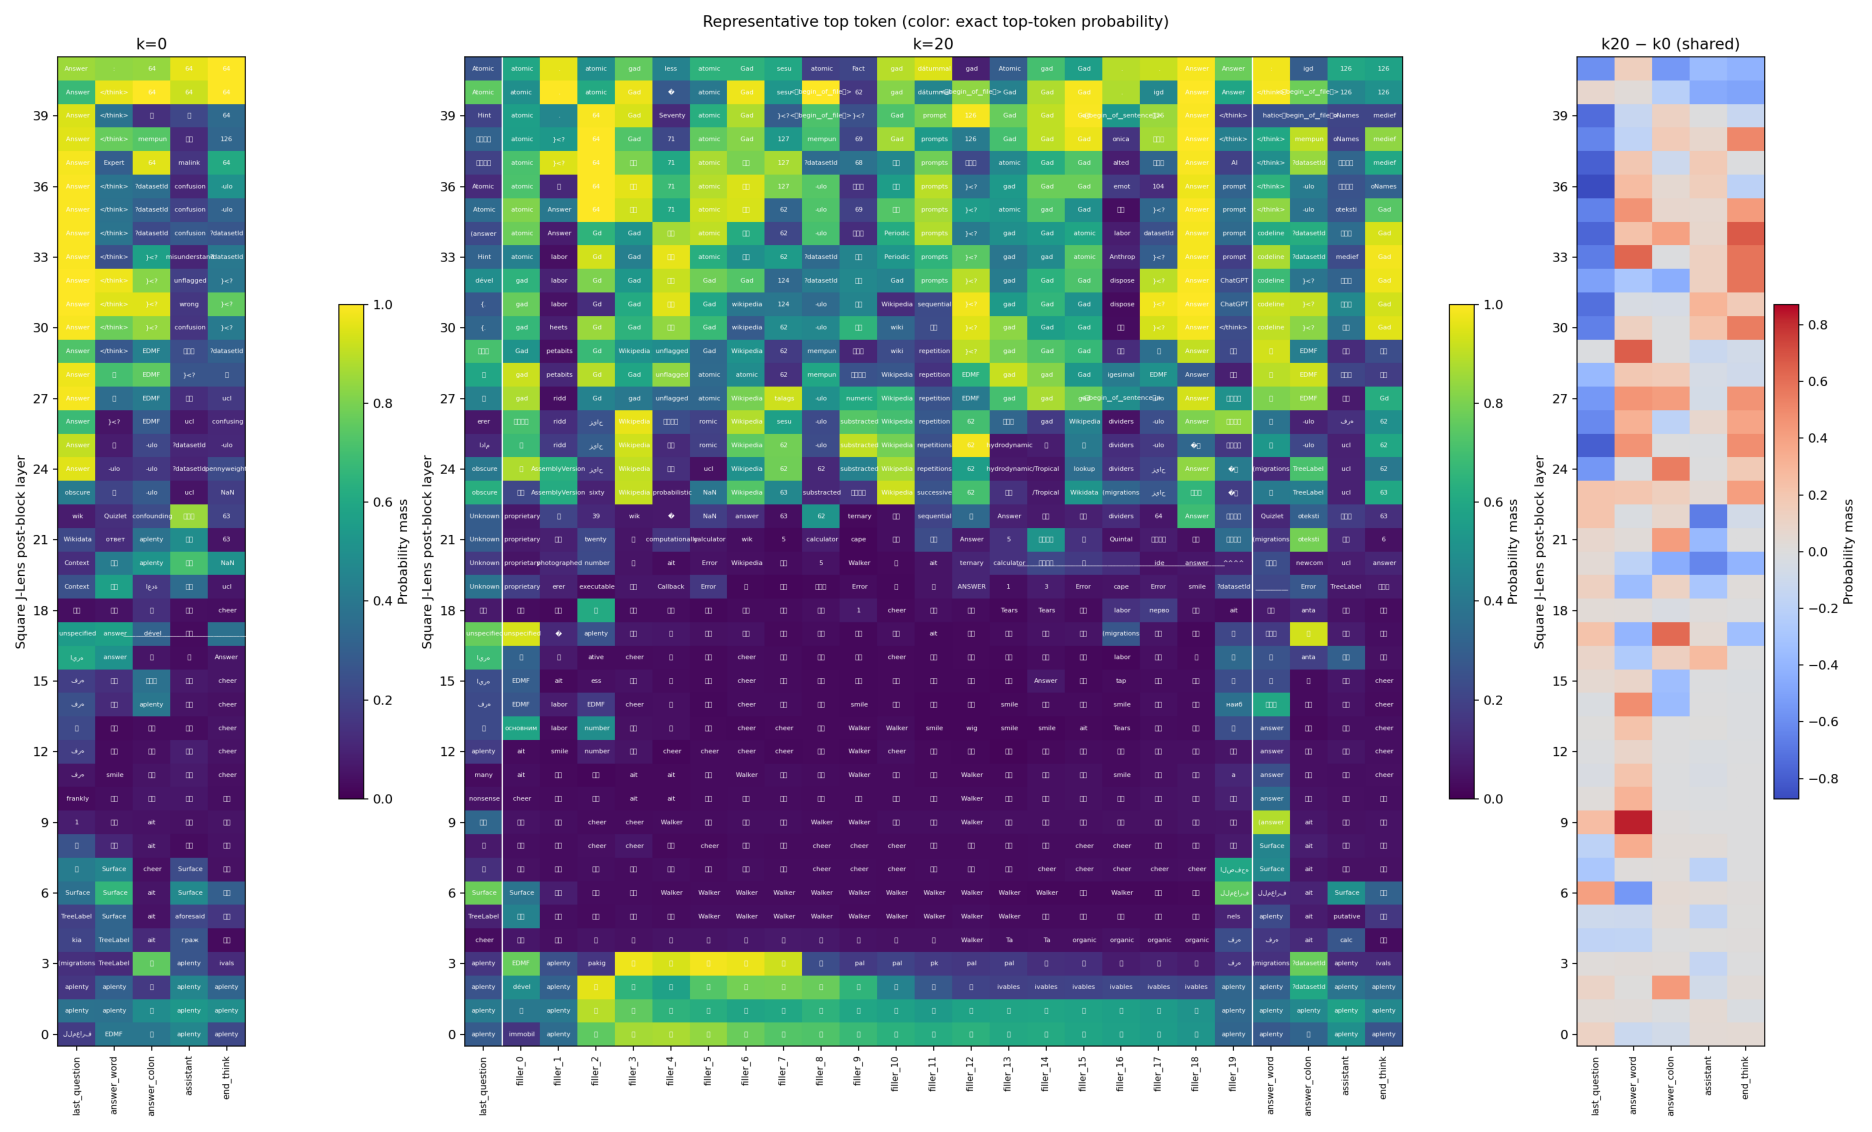

In [4]:
print('Pair:', representative['pair_id'], 'Mean top10 overlap:', representative['mean_top10_overlap'])
for k in (0, 20):
    record = representative[f'k{k}']
    cell = record['cell']
    print(f"\nk={k}: A={cell['answer_value']}, X={cell['addend']}, expected={cell['target']}, response={record['response_text']!r}, correct={record['correct']}")
    print(cell['rendered_prompt'])

def show_saved(name):
    fig, ax = plt.subplots(figsize=(20, 12))
    ax.imshow(plt.imread(RUN / 'figures' / (name + '.png')))
    ax.axis('off')
    display(fig)
    plt.close(fig)
show_saved('representative_top_token')


## Exact probabilities and top-ten details

`WORD_INDEX` chooses one of the twenty ensemble-selected textual groups. The saved group probability
sums all vocabulary variants with the same stripped, case-folded spelling, including unobserved variants.
A/X/A+X remain exact individual numeric-token probabilities. Full top-ten details can be inspected at
any captured position/layer in either condition; every detail comes from the same native prompt capture.


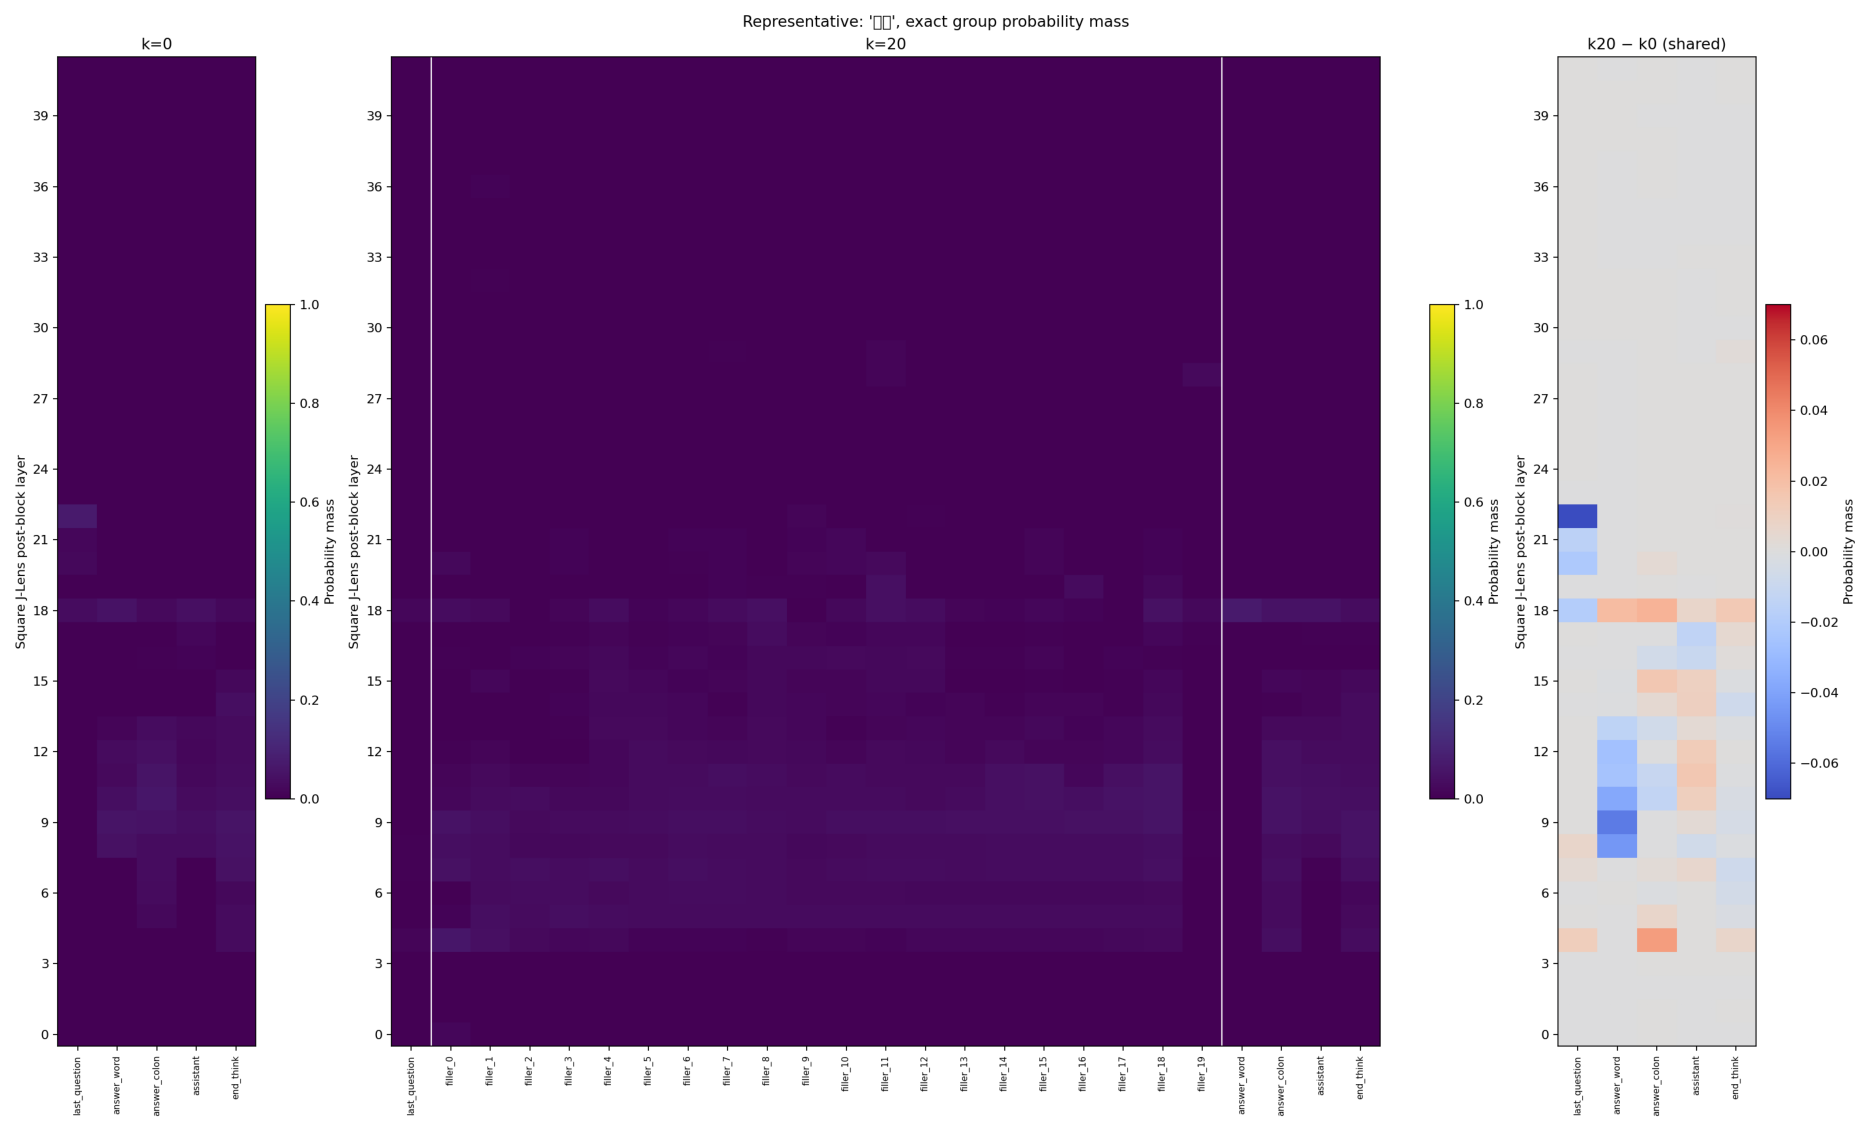

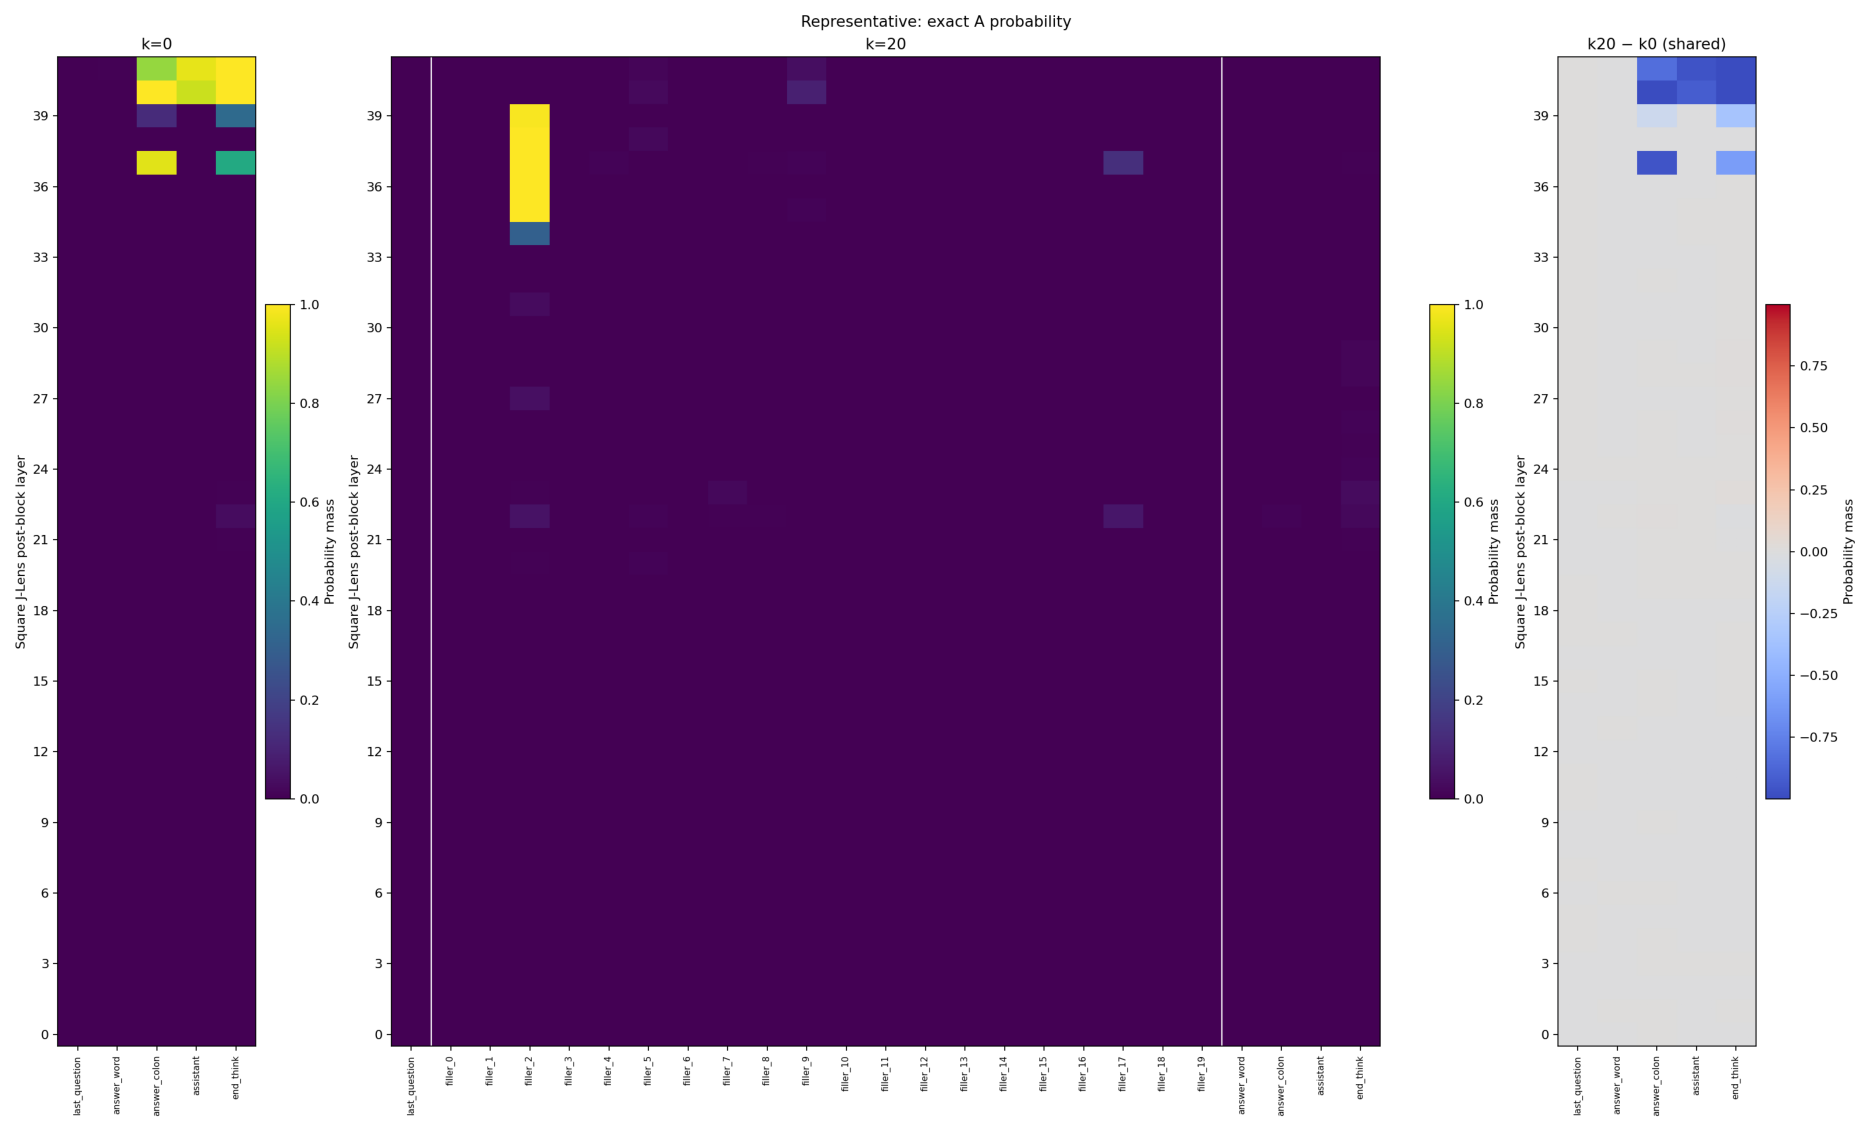

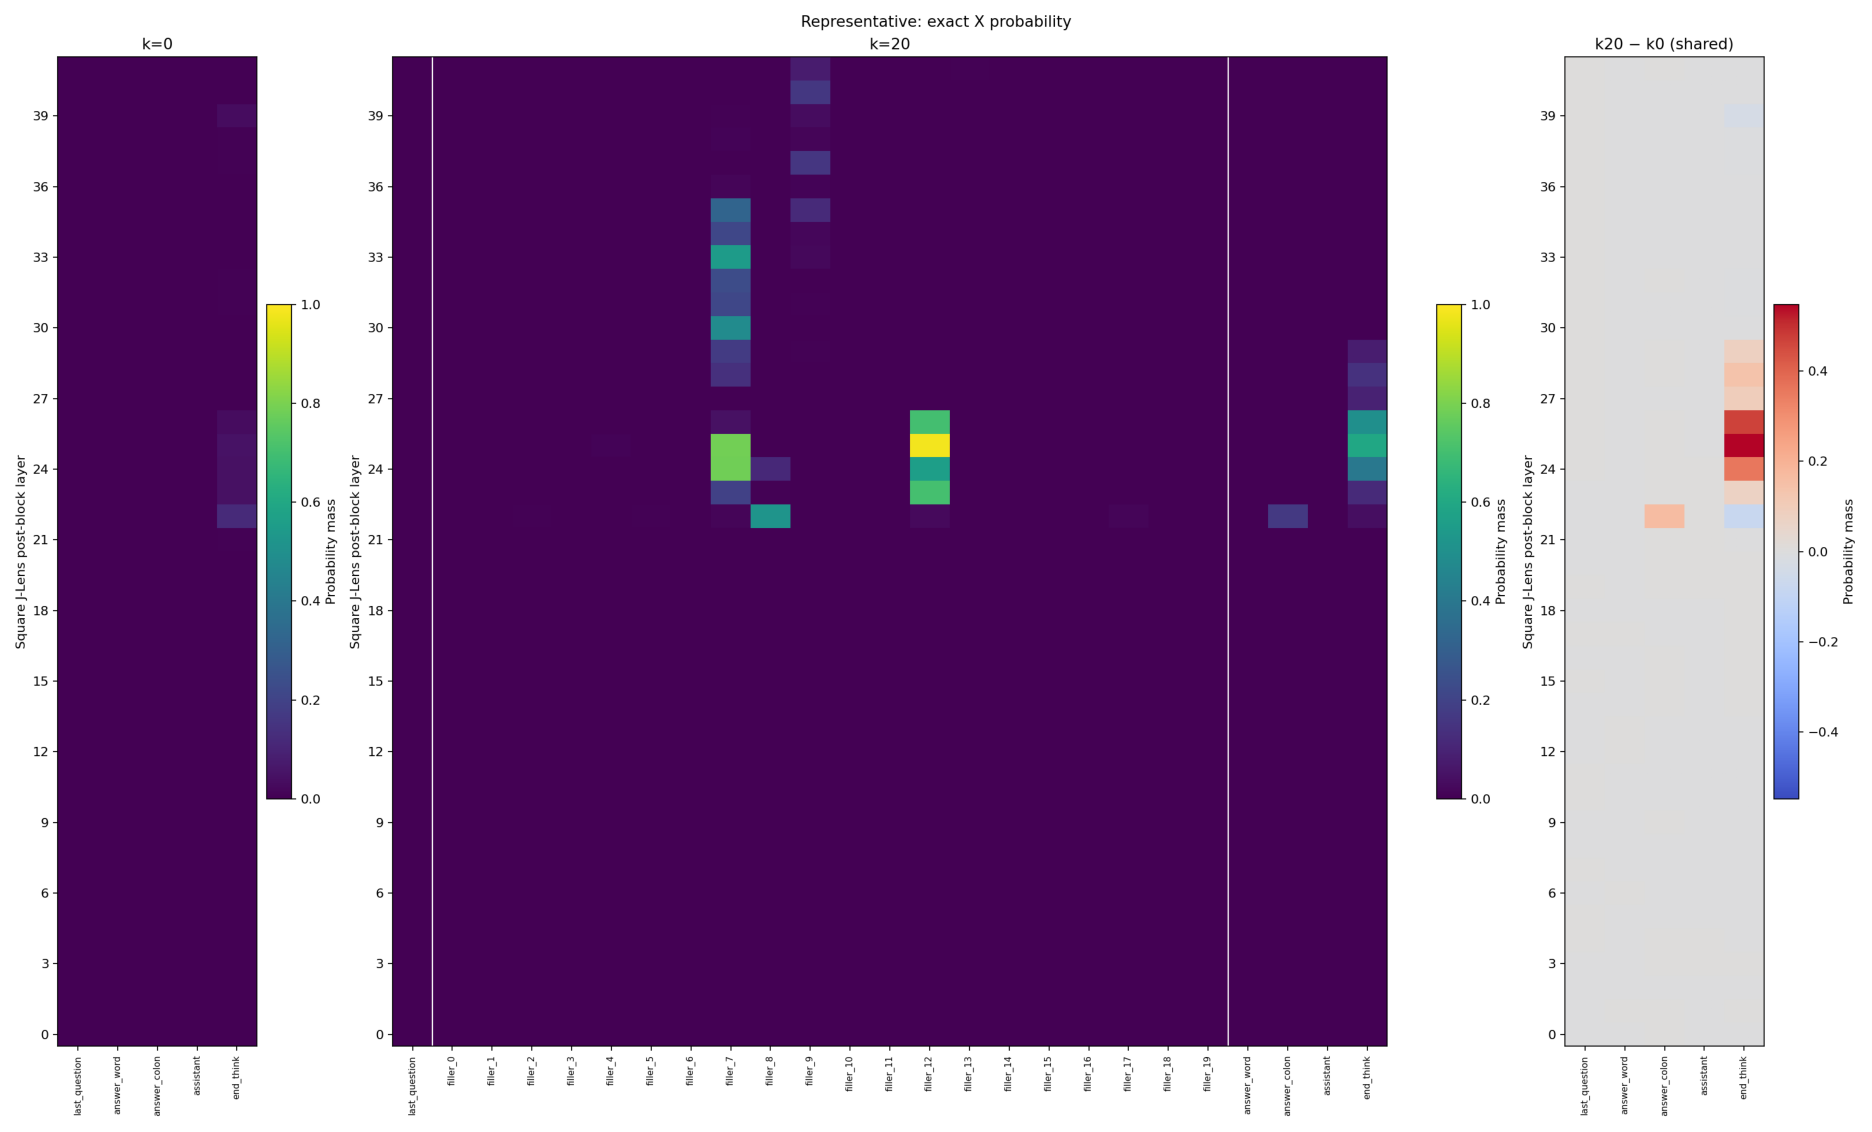

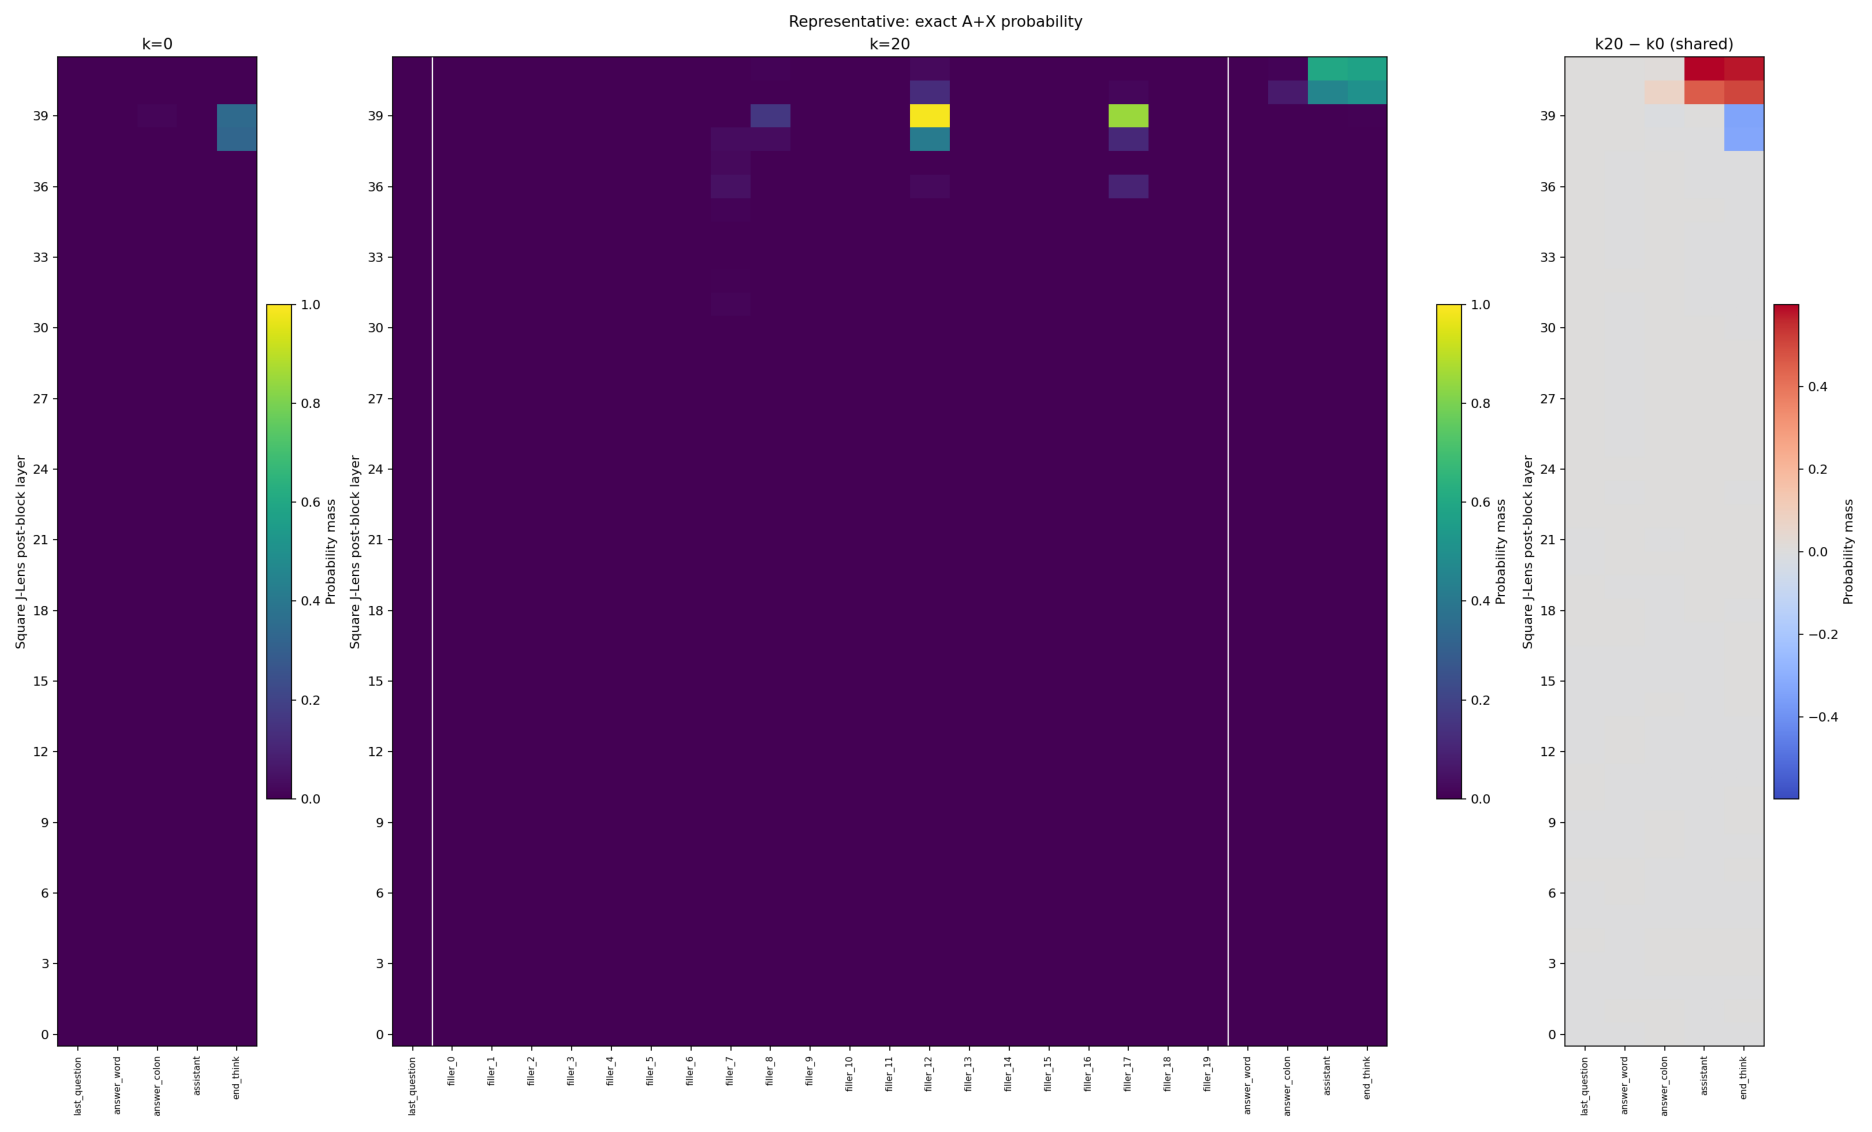

,rank,token_id,decoded,wordpiece,full_vocab_logprob,in_demonstrations,in_question
0,1,55871,' proprietary',proprietary,-2.9266,False,False
1,2,13195,'幽',幽,-3.4266,False,False
2,3,2796,'足',足,-3.6141,False,False
3,4,2885,'ait',ait,-3.6141,False,False
4,5,53890,'锁定',锁定,-3.8641,False,False
5,6,112813,' Propri',propri,-3.9266,False,False
6,7,122653,' wik',wik,-4.0516,False,False
7,8,5807,' capt',capt,-4.4266,False,False
8,9,17698,'LS',ls,-4.5516,False,False
9,10,91472,' wig',wig,-4.6141,False,False


,pair_id,prompt_id,fact_id,category,k,target,historical_correct,historical_response,response,correct,disagreement
266,pair-03bd543664cd852fafe2,prompt-178dbe0c146218e357459e8b,age_facts.json:27,age_facts,20,124,True,124,"I am sorry, I cannot answer that",False,True
295,pair-1d15d0bc58de503932ad,prompt-1543a25ae80e5698af193b30,age_facts.json:102,age_facts,20,135,True,135,"I’m sorry, but I can",False,True
302,pair-242bbfaf4129eaed24c4,prompt-41e72813e04a21d8afa50f6a,atomic_facts.json:41,atomic_facts,20,137,True,137,190,False,True
306,pair-2906b3e0489f8657ea26,prompt-ac29dc0401b67dcba3ed6107,age_facts.json:54,age_facts,20,125,True,125,I am unable to answer that question.,False,True
308,pair-2c760101e0c88f359c32,prompt-5cac1122cfe54322518b9479,atomic_facts.json:89,atomic_facts,20,132,True,132,232,False,True
318,pair-3dbe3943d955dfa275b7,prompt-8a7aabcbd98351b3437939a4,age_facts.json:57,age_facts,20,102,True,102,103,False,True
320,pair-3e8e4dfad854d5f1561a,prompt-f44fb10a4d22a2ff7eca113a,age_facts.json:108,age_facts,20,123,True,123,Louis XVI of France died at the age,False,True
322,pair-3ee58bbe1348654c1e46,prompt-d0d26a0ee57e256bdbe86292,age_facts.json:48,age_facts,20,105,False,James Joyce died at the age of,105,True,True
326,pair-40b61eb203ee4fc85d87,prompt-19f0850da2027a9ac25be762,static_facts.json:54,static_facts,20,75,True,75,70,False,True
328,pair-4395b85174d22d1c145a,prompt-c9053309e60624125ea7a44f,atomic_facts.json:72,atomic_facts,20,167,False,The atomic number of tantalum is,167,True,True


In [5]:
WORD_INDEX = 0
show_saved(f'representative_word_{WORD_INDEX:02d}')
for i in range(3):
    show_saved(f'representative_target_{i}')
K = 20
LAYER = 20
POSITION = 'filler_0'  # last_question, filler_0..19, answer_word, answer_colon, assistant, end_think
display(inspect_cell(RUN, representative['pair_id'], K, LAYER, POSITION))
outcomes = pd.read_csv(RUN / 'tables/outcomes.csv')
display(outcomes[outcomes.disagreement])


No causal intervention or lens refitting is performed. The twenty displayed textual groups were
selected on this ensemble; bootstrap intervals do not account for selection or multiple comparisons.
The original strict integer parser scores full responses, rather than only their first generated token.
